# Different depths

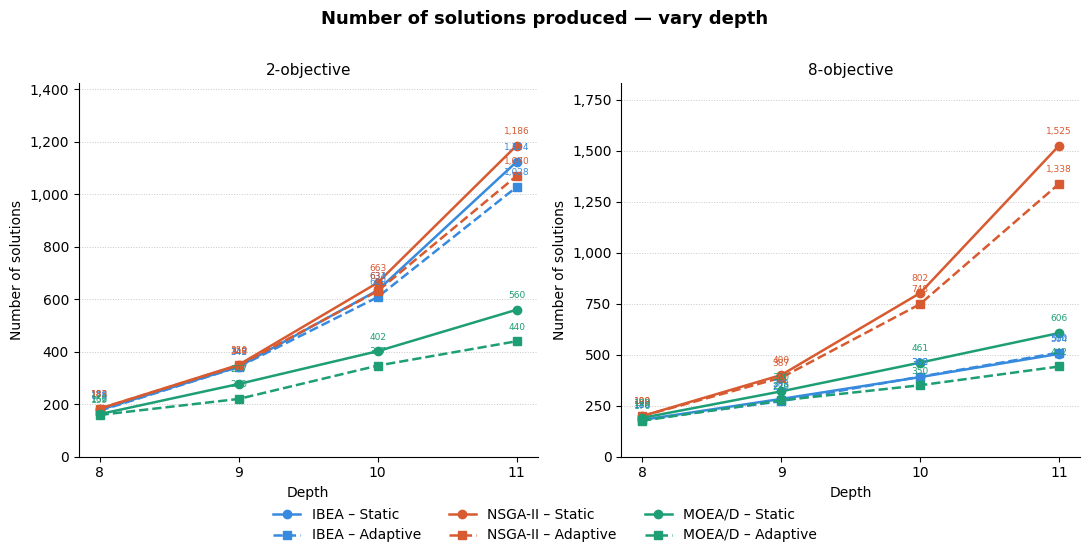

Saved vary_depth.png


In [3]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Style config ──────────────────────────────────────────────────────────────
ALGO_LABELS = {"IBEA": "IBEA", "NSGAII": "NSGA-II", "MOEAD": "MOEA/D"}
ALGO_COLORS = {"IBEA": "#378ADD", "NSGAII": "#D85A30", "MOEAD": "#1D9E75"}
SETTING_STYLE = {"intertemporal": "-", "table": "--"}
SETTING_MARK = {"intertemporal": "o", "table": "s"}
SETTING_LABEL = {"intertemporal": "Static", "table": "Adaptive"}

ALGOS = ["IBEA", "NSGAII", "MOEAD"]

DEPTH_RE = re.compile(r"data_(\d+)_\d+$")
LEAF_RE = re.compile(
    r"(intertemporal|table)_(IBEA|NSGAII|MOEAD)_single_(many|multi)_obj_\w+"
)


# ── Helper ────────────────────────────────────────────────────────────────────
def count_solutions(filepath):
    with open(filepath) as f:
        return sum(1 for _ in f) - 1


# ── Loader ────────────────────────────────────────────────────────────────────
def load_dataset(base="./tree_data/moea_depth_vary"):
    records = []
    for entry in sorted(os.listdir(base)):
        m_depth = DEPTH_RE.match(entry)
        if not m_depth:
            continue
        depth = int(m_depth.group(1))
        for folder in sorted(os.listdir(os.path.join(base, entry))):
            m = LEAF_RE.match(folder)
            if not m:
                continue
            setting, algo, obj = m.group(1), m.group(2), m.group(3)
            folder_path = os.path.join(base, entry, folder)
            csv_files = [f for f in os.listdir(folder_path)
                         if f.startswith("archives_") and f.endswith(".csv")]
            if not csv_files:
                continue
            filepath = os.path.join(folder_path, sorted(csv_files)[0])
            records.append(dict(
                depth=depth, algo=algo, setting=setting, obj=obj,
                solutions=count_solutions(filepath),
            ))
    return pd.DataFrame(records)


# ── Plotting helper ───────────────────────────────────────────────────────────
def plot_lines(ax, df, x_col, x_vals, obj_filter, x_label, title):
    subset = df[df["obj"] == obj_filter] if obj_filter else df
    for algo in ALGOS:
        for setting in ["intertemporal", "table"]:
            data = (
                subset[(subset["algo"] == algo) & (subset["setting"] == setting)]
                    .set_index(x_col)["solutions"]
                    .reindex(x_vals)
            )
            line, = ax.plot(
                x_vals, data.values,
                color=ALGO_COLORS[algo],
                linestyle=SETTING_STYLE[setting],
                marker=SETTING_MARK[setting],
                linewidth=1.8, markersize=6,
                label=f"{ALGO_LABELS[algo]} – {SETTING_LABEL[setting]}",
            )
            # Label each data point
            for x, y in zip(x_vals, data.values):
                if pd.notna(y):
                    ax.annotate(
                        f"{int(y):,}",
                        xy=(x, y),
                        xytext=(0, 7),
                        textcoords="offset points",
                        ha="center", va="bottom",
                        fontsize=6.5,
                        color=ALGO_COLORS[algo],
                    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel("Number of solutions", fontsize=10)
    ax.set_xticks(x_vals)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    # Add headroom for labels
    ymax = subset["solutions"].max()
    ax.set_ylim(0, ymax * 1.2)


def add_legend(fig, ax):
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=10)


# ── Main ──────────────────────────────────────────────────────────────────────
df = load_dataset()
DEPTHS = sorted(df["depth"].unique())

os.makedirs("./tree_figures", exist_ok=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Number of solutions produced — vary depth",
             fontsize=13, fontweight="bold", y=1.01)

plot_lines(ax1, df, "depth", DEPTHS, "multi", "Depth", "2-objective")
plot_lines(ax2, df, "depth", DEPTHS, "many",  "Depth", "8-objective")
add_legend(fig, ax1)

fig.tight_layout()
fig.savefig("./tree_figures/vary_depth.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved vary_depth.png")

# Different numbers of objectives

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from morl_baselines.common.performance_indicators import hypervolume

# ── Style config ──────────────────────────────────────────────────────────────
ALGO_LABELS  = {"IBEA": "IBEA", "NSGAII": "NSGA-II", "MOEAD": "MOEA/D"}
ALGO_COLORS  = {"IBEA": "#378ADD", "NSGAII": "#D85A30", "MOEAD": "#1D9E75"}
POLICY_STYLE = {"intertemporal": "-",  "table": "--"}
POLICY_MARK  = {"intertemporal": "o",  "table": "s"}
POLICY_LABEL = {"intertemporal": "Intertemporal", "table": "Table"}
ALGOS        = ["IBEA", "NSGAII", "MOEAD"]
POLICIES     = ["intertemporal", "table"]


# ── Loader ────────────────────────────────────────────────────────────────────
def load_dataset(base):
    """
    Folder pattern: {policy}_{algo}_single_{n_obj}_observable
    Reads _combined.csv archive, computes hypervolume.
    Returns DataFrame: policy, algo, n_obj, hv
    """
    folder_re = re.compile(
        r'^(intertemporal|table)_(NSGAII|IBEA|MOEAD)_single_(\d+)_observable$'
    )
    records = []
    for d in os.listdir(base):
        m = folder_re.match(d)
        if not m:
            continue
        policy, algo, n_obj = m.group(1), m.group(2), int(m.group(3))
        folder_path = os.path.join(base, d)

        csvs = sorted([f for f in os.listdir(folder_path)
                       if f.startswith('archives_') and f.endswith('_combined.csv')])
        if not csvs:
            csvs = sorted([f for f in os.listdir(folder_path)
                           if f.startswith('archives_') and f.endswith('.csv')])
        if not csvs:
            continue

        df = pd.read_csv(os.path.join(folder_path, csvs[0]))
        obj_cols = [c for c in df.columns if c.startswith('o')]
        if not obj_cols:
            continue

        vals = np.abs(df[obj_cols].values)
        ref  = np.full(len(obj_cols), -1.0)
        hv   = hypervolume(ref, [tuple(r) for r in vals]) if len(vals) > 0 else 0.0

        records.append({'policy': policy, 'algo': algo, 'n_obj': n_obj, 'hv': hv})

    return pd.DataFrame(records).sort_values(['policy', 'algo', 'n_obj'])


# ── Plotting helper ───────────────────────────────────────────────────────────
def plot_lines(ax, df, n_obj_vals, policy, title):
    subset = df[df['policy'] == policy]
    for algo in ALGOS:
        data = (subset[subset['algo'] == algo]
                .set_index('n_obj')['hv']
                .reindex(n_obj_vals))
        ax.plot(
            n_obj_vals, data.values,
            color=ALGO_COLORS[algo],
            linestyle=POLICY_STYLE[policy],
            marker=POLICY_MARK[policy],
            linewidth=1.8, markersize=6,
            label=ALGO_LABELS[algo],
        )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Number of objectives', fontsize=10)
    ax.set_ylabel('Hypervolume', fontsize=10)
    ax.set_xticks(n_obj_vals)
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    BASE = './tree_data/moea_obj_vary'
    OUT  = './tree_figures'
    os.makedirs(OUT, exist_ok=True)

    df = load_dataset(BASE)
    n_obj_vals = sorted(df['n_obj'].unique())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharey=False)
    fig.suptitle('Hypervolume vs number of objectives — MOEA single deterministic',
                 fontsize=13, fontweight='bold', y=1.01)

    plot_lines(ax1, df, n_obj_vals, 'intertemporal', 'Intertemporal policy')
    plot_lines(ax2, df, n_obj_vals, 'table',         'Table policy')

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=10)

    fig.tight_layout()
    out_path = os.path.join(OUT, 'hv_vs_n_obj.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

# Observability

Saved ./tree_figures/hv_observability.png


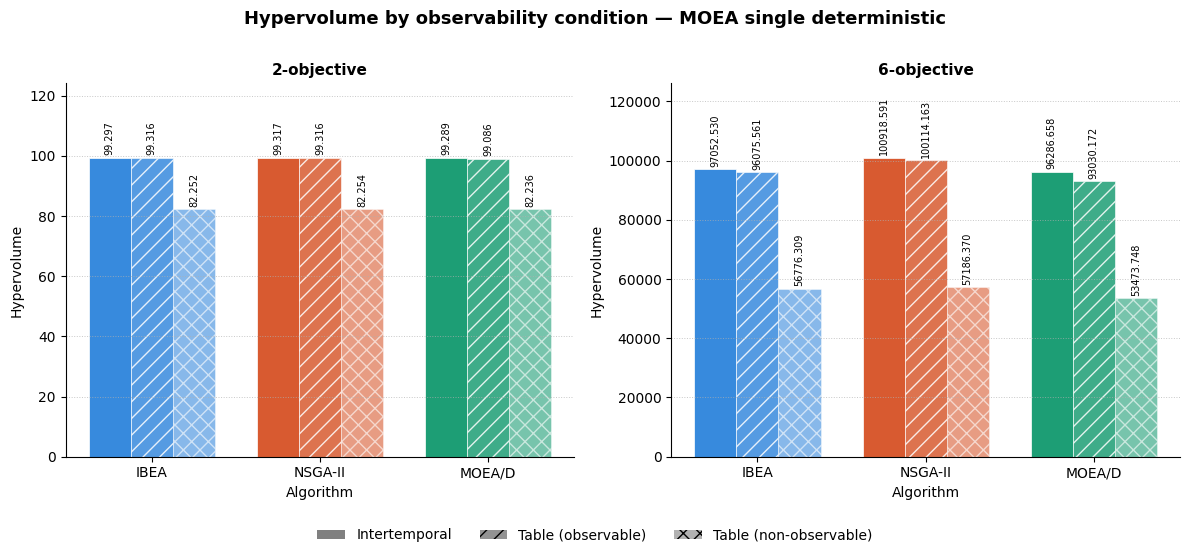

In [9]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from morl_baselines.common.performance_indicators import hypervolume

# ── Style config ──────────────────────────────────────────────────────────────
ALGO_LABELS  = {"IBEA": "IBEA", "NSGAII": "NSGA-II", "MOEAD": "MOEA/D"}
ALGO_COLORS  = {"IBEA": "#378ADD", "NSGAII": "#D85A30", "MOEAD": "#1D9E75"}

COND_LABEL = {
    "intertemporal_observable":  "Intertemporal",
    "table_observable":          "Table (observable)",
    "table_non_observable":      "Table (non-observable)",
}

ALGOS      = ["IBEA", "NSGAII", "MOEAD"]
CONDITIONS = ["intertemporal_observable", "table_observable", "table_non_observable"]
N_OBJS     = [2, 6]


# ── Loader ────────────────────────────────────────────────────────────────────
def load_dataset(base):
    folder_re = re.compile(
        r'^(intertemporal|table)_(NSGAII|IBEA|MOEAD)_single_(\d+)_(observable|non_observable)$'
    )
    records = []
    for d in os.listdir(base):
        m = folder_re.match(d)
        if not m:
            continue
        policy, algo, n_obj, obs = (m.group(1), m.group(2),
                                    int(m.group(3)), m.group(4))
        condition = f"{policy}_{obs}"
        if condition not in CONDITIONS:
            continue

        folder_path = os.path.join(base, d)
        csvs = sorted([f for f in os.listdir(folder_path)
                       if f.startswith('archives_') and f.endswith('_combined.csv')])
        if not csvs:
            csvs = sorted([f for f in os.listdir(folder_path)
                           if f.startswith('archives_') and f.endswith('.csv')])
        if not csvs:
            continue

        df = pd.read_csv(os.path.join(folder_path, csvs[0]))
        obj_cols = [c for c in df.columns if c.startswith('o')]
        if not obj_cols:
            continue

        vals = np.abs(df[obj_cols].values)
        ref  = np.full(len(obj_cols), -1.0)
        hv   = hypervolume(ref, [tuple(r) for r in vals]) if len(vals) > 0 else 0.0

        records.append({'condition': condition, 'algo': algo,
                        'n_obj': n_obj, 'hv': hv})

    return pd.DataFrame(records)


# ── Plotting helper ───────────────────────────────────────────────────────────
def plot_bars(ax, df, n_obj, title):
    subset  = df[df['n_obj'] == n_obj]
    x       = np.arange(len(ALGOS))
    width   = 0.25
    offsets = [-width, 0, width]

    for offset, cond in zip(offsets, CONDITIONS):
        hv_vals = [subset.loc[
                       (subset['algo'] == algo) & (subset['condition'] == cond),
                       'hv'].values[0]
                   if len(subset.loc[
                       (subset['algo'] == algo) & (subset['condition'] == cond)]) > 0
                   else 0.0
                   for algo in ALGOS]
        alpha = 1.0 if cond == 'intertemporal_observable' else \
                0.85 if cond == 'table_observable' else 0.6
        hatch = '' if cond == 'intertemporal_observable' else \
                '//' if cond == 'table_observable' else 'xx'

        bars = ax.bar(x + offset, hv_vals, width=width,
                      label=COND_LABEL[cond],
                      color=[ALGO_COLORS[a] for a in ALGOS],
                      alpha=alpha,
                      edgecolor='white', linewidth=0.5,
                      hatch=hatch)

        ax.bar_label(bars,
                     labels=[f'{v:.3f}' for v in hv_vals],
                     padding=2, fontsize=7, rotation=90)

    max_hv = subset['hv'].max() if not subset.empty else 1.0
    ax.set_ylim(0, max_hv * 1.25)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Algorithm', fontsize=10)
    ax.set_ylabel('Hypervolume', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([ALGO_LABELS[a] for a in ALGOS])
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    BASE = './tree_data/moea_observable'
    OUT  = './tree_figures'
    os.makedirs(OUT, exist_ok=True)

    df = load_dataset(BASE)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    fig.suptitle('Hypervolume by observability condition — MOEA single deterministic',
                 fontsize=13, fontweight='bold', y=1.01)

    plot_bars(ax1, df, n_obj=2, title='2-objective')
    plot_bars(ax2, df, n_obj=6, title='6-objective')

    legend_handles = [
        Patch(facecolor='grey', alpha=1.0,  hatch='',   label=COND_LABEL['intertemporal_observable']),
        Patch(facecolor='grey', alpha=0.85, hatch='//', label=COND_LABEL['table_observable']),
        Patch(facecolor='grey', alpha=0.6,  hatch='xx', label=COND_LABEL['table_non_observable']),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=10)

    fig.tight_layout()
    out_path = os.path.join(OUT, 'hv_observability.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

# Different selectors (MORL)

Saved ./tree_figures/hv_morl_selector.png


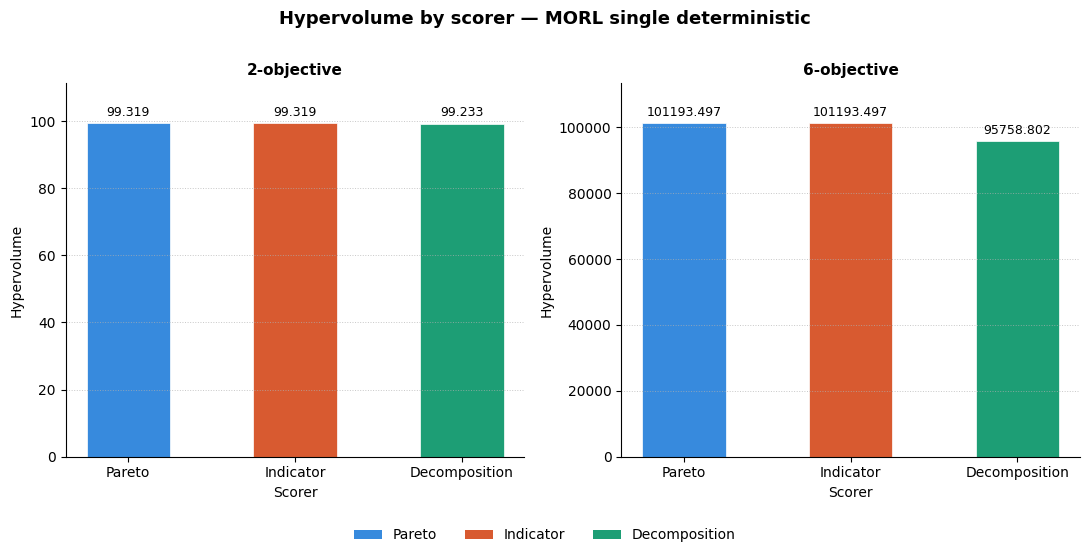

In [8]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from morl_baselines.common.performance_indicators import hypervolume

# ── Style config ──────────────────────────────────────────────────────────────
SCORING_LABELS = {
    "pareto":        "Pareto",
    "indicator":     "Indicator",
    "decomposition": "Decomposition",
}
SCORING_COLORS = {
    "pareto":        "#378ADD",
    "indicator":     "#D85A30",
    "decomposition": "#1D9E75",
}

SCORINGS = ["pareto", "indicator", "decomposition"]
OBJ_MAP  = {"multi_obj": 2, "many_obj": 6}


# ── Loader ────────────────────────────────────────────────────────────────────
def load_dataset(base):
    """
    Folder pattern: {scoring}_single_{multi|many}_obj
    Reads pcs_*.csv (positive values, maximisation convention).
    Returns DataFrame: scoring, n_obj, hv
    """
    folder_re = re.compile(r'^(pareto|indicator|decomposition)_single_(multi|many)_obj$')
    records = []
    for d in os.listdir(base):
        m = folder_re.match(d)
        if not m:
            continue
        scoring, obj_key = m.group(1), f"{m.group(2)}_obj"
        n_obj = OBJ_MAP[obj_key]
        folder_path = os.path.join(base, d)

        csvs = sorted([f for f in os.listdir(folder_path)
                       if f.startswith('pcs_') and f.endswith('.csv')])
        if not csvs:
            continue

        df = pd.read_csv(os.path.join(folder_path, csvs[0]))
        obj_cols = [c for c in df.columns if c.startswith('o')]
        if not obj_cols:
            continue

        vals = df[obj_cols].values
        ref  = np.full(len(obj_cols), -1.0)
        hv   = hypervolume(ref, [tuple(r) for r in vals]) if len(vals) > 0 else 0.0

        records.append({'scoring': scoring, 'n_obj': n_obj, 'hv': hv})

    return pd.DataFrame(records)


# ── Plot ──────────────────────────────────────────────────────────────────────
def plot_bars(ax, df, n_obj, title):
    """One bar per scorer with value label on top."""
    subset  = df[df['n_obj'] == n_obj]
    x       = np.arange(len(SCORINGS))
    hv_vals = [subset.loc[subset['scoring'] == s, 'hv'].values[0]
               if len(subset[subset['scoring'] == s]) > 0 else 0.0
               for s in SCORINGS]

    bars = ax.bar(x, hv_vals,
                  width=0.5,
                  color=[SCORING_COLORS[s] for s in SCORINGS],
                  edgecolor='white', linewidth=0.5)

    ax.bar_label(bars,
                 labels=[f'{v:.3f}' for v in hv_vals],
                 padding=3, fontsize=9)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Scorer', fontsize=10)
    ax.set_ylabel('Hypervolume', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([SCORING_LABELS[s] for s in SCORINGS])
    ax.set_ylim(0, max(hv_vals) * 1.12 if max(hv_vals) > 0 else 1)
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    BASE = './tree_data/morl_selector'
    OUT  = './tree_figures'
    os.makedirs(OUT, exist_ok=True)

    df = load_dataset(BASE)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharey=False)
    fig.suptitle('Hypervolume by scorer — MORL single deterministic',
                 fontsize=13, fontweight='bold', y=1.01)

    plot_bars(ax1, df, n_obj=2, title='2-objective')
    plot_bars(ax2, df, n_obj=6, title='6-objective')

    handles = [Patch(facecolor=SCORING_COLORS[s], label=SCORING_LABELS[s])
               for s in SCORINGS]
    fig.legend(handles=handles, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=10)

    fig.tight_layout()
    out_path = os.path.join(OUT, 'hv_morl_selector.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

# Robustness

Saved ./tree_figures/hv_robust.png


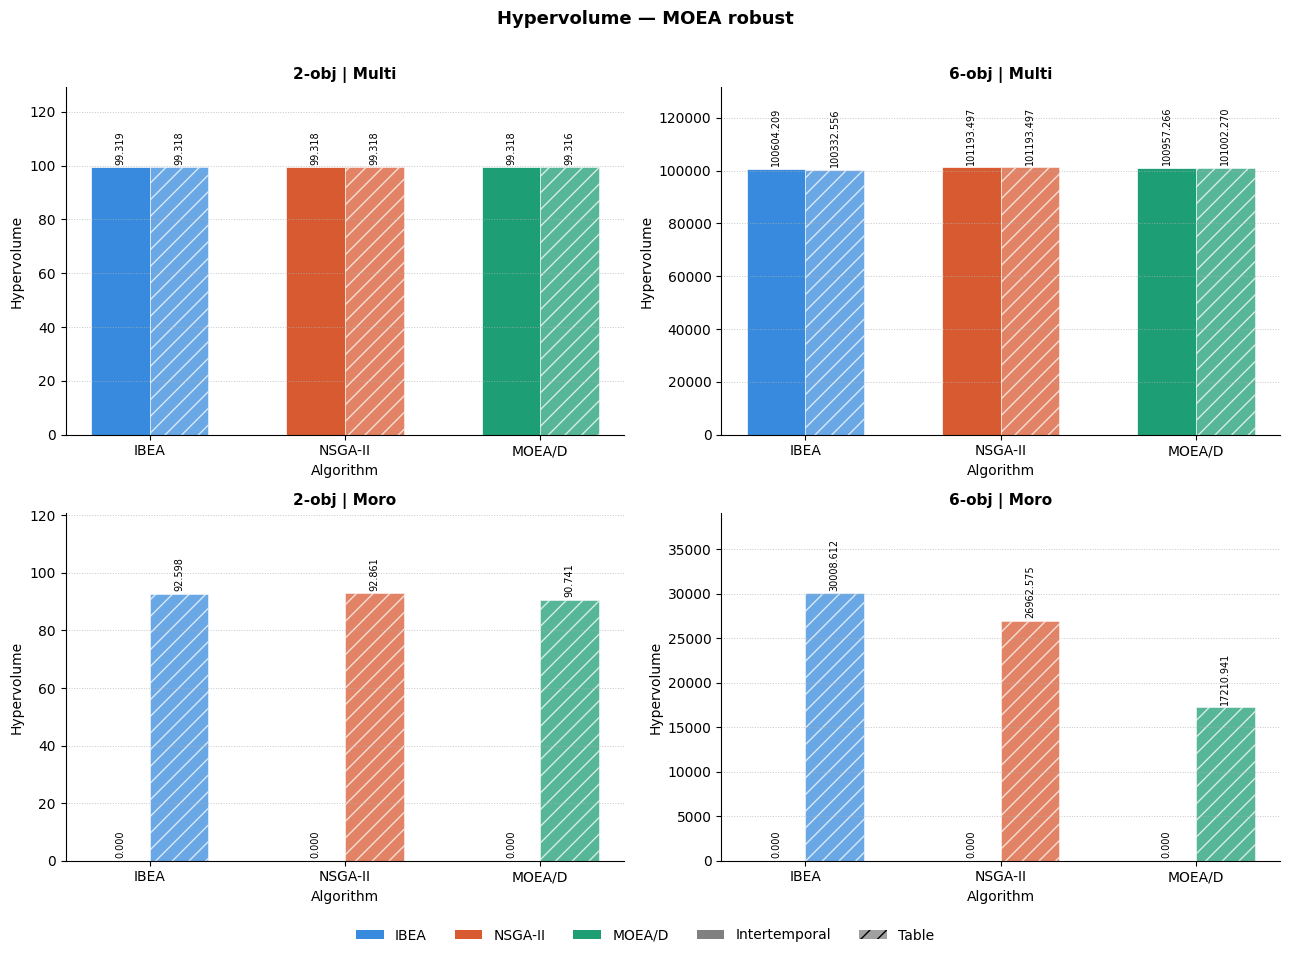

In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from morl_baselines.common.performance_indicators import hypervolume

# ── Style config ──────────────────────────────────────────────────────────────
ALGO_LABELS  = {"IBEA": "IBEA", "NSGAII": "NSGA-II", "MOEAD": "MOEA/D"}
ALGO_COLORS  = {"IBEA": "#378ADD", "NSGAII": "#D85A30", "MOEAD": "#1D9E75"}
POLICY_HATCH = {"intertemporal": "", "table": "//"}
POLICY_ALPHA = {"intertemporal": 1.0, "table": 0.75}
POLICY_LABEL = {"intertemporal": "Intertemporal", "table": "Table"}

ALGOS    = ["IBEA", "NSGAII", "MOEAD"]
POLICIES = ["intertemporal", "table"]
OBJ_MAP  = {"multi_obj": 2, "many_obj": 6}


# ── Loader ────────────────────────────────────────────────────────────────────
def load_dataset(base):
    """
    Folder pattern: {policy}_{algo}_{scenario}_{multi|many}_obj_robust
    scenario: multi or moro
    Returns DataFrame: policy, algo, scenario, n_obj, hv
    """
    folder_re = re.compile(
        r'^(intertemporal|table)_(NSGAII|IBEA|MOEAD)_(multi|moro)_(multi|many)_obj_robust$'
    )
    records = []
    for d in os.listdir(base):
        m = folder_re.match(d)
        if not m:
            continue
        policy, algo, scenario, obj_key = (
            m.group(1), m.group(2), m.group(3), f"{m.group(4)}_obj")
        n_obj = OBJ_MAP[obj_key]
        folder_path = os.path.join(base, d)

        # moro table uses pruned file (positive values);
        # all others use combined file (negated values, apply abs)
        if scenario == 'moro' and policy == 'table':
            csvs = sorted([f for f in os.listdir(folder_path)
                           if f.startswith('archives_') and f.endswith('_pruned.csv')])
            negate = False
        else:
            csvs = sorted([f for f in os.listdir(folder_path)
                           if f.startswith('archives_') and f.endswith('_combined.csv')])
            negate = True
            if not csvs:
                csvs = sorted([f for f in os.listdir(folder_path)
                               if f.startswith('archives_') and f.endswith('.csv')
                               and '_pruned' not in f])

        if not csvs:
            continue

        df = pd.read_csv(os.path.join(folder_path, csvs[0]))
        obj_cols = [c for c in df.columns if c == 'o1' or
                    (c.startswith('o') and c[1:].isdigit())]
        if not obj_cols:
            continue

        vals = np.abs(df[obj_cols].values) if negate else df[obj_cols].values
        ref  = np.full(len(obj_cols), -1.0)
        hv   = hypervolume(ref, [tuple(r) for r in vals]) if len(vals) > 0 else 0.0

        records.append({'policy': policy, 'algo': algo,
                        'scenario': scenario, 'n_obj': n_obj, 'hv': hv})

    return pd.DataFrame(records)


# ── Plotting helper ───────────────────────────────────────────────────────────
def plot_bars(ax, df, n_obj, scenario, title):
    """Grouped bars: x = algorithm, two bars per group (intertemporal, table)."""
    subset  = df[(df['n_obj'] == n_obj) & (df['scenario'] == scenario)]
    x       = np.arange(len(ALGOS))
    width   = 0.3
    offsets = [-width / 2, width / 2]

    for offset, policy in zip(offsets, POLICIES):
        hv_vals = []
        for algo in ALGOS:
            row = subset[(subset['algo'] == algo) & (subset['policy'] == policy)]
            hv_vals.append(row['hv'].values[0] if len(row) > 0 else 0.0)

        bars = ax.bar(x + offset, hv_vals,
                      width=width,
                      color=[ALGO_COLORS[a] for a in ALGOS],
                      alpha=POLICY_ALPHA[policy],
                      hatch=POLICY_HATCH[policy],
                      edgecolor='white', linewidth=0.5,
                      label=POLICY_LABEL[policy])

        ax.bar_label(bars,
                     labels=[f'{v:.3f}' for v in hv_vals],
                     padding=2, fontsize=7, rotation=90)

    max_hv = subset['hv'].max() if not subset.empty else 1.0
    ax.set_ylim(0, max_hv * 1.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Algorithm', fontsize=10)
    ax.set_ylabel('Hypervolume', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([ALGO_LABELS[a] for a in ALGOS])
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    BASE = './tree_data/moea_robust'
    OUT  = './tree_figures'
    os.makedirs(OUT, exist_ok=True)

    df = load_dataset(BASE)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=False)
    fig.suptitle('Hypervolume — MOEA robust',
                 fontsize=13, fontweight='bold', y=1.01)

    plot_bars(axes[0, 0], df, n_obj=2, scenario='multi', title='2-obj | Multi')
    plot_bars(axes[0, 1], df, n_obj=6, scenario='multi', title='6-obj | Multi')
    plot_bars(axes[1, 0], df, n_obj=2, scenario='moro',  title='2-obj | Moro')
    plot_bars(axes[1, 1], df, n_obj=6, scenario='moro',  title='6-obj | Moro')

    # Shared legend
    algo_handles   = [Patch(facecolor=ALGO_COLORS[a], label=ALGO_LABELS[a])
                      for a in ALGOS]
    policy_handles = [Patch(facecolor='grey', alpha=POLICY_ALPHA[p],
                            hatch=POLICY_HATCH[p], label=POLICY_LABEL[p])
                      for p in POLICIES]
    fig.legend(handles=algo_handles + policy_handles,
               loc='lower center', ncol=len(ALGOS) + len(POLICIES),
               bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=10)

    fig.tight_layout()
    out_path = os.path.join(OUT, 'hv_robust.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

# Robustness (MORL)

Saved ./tree_figures/hv_morl_selector.png


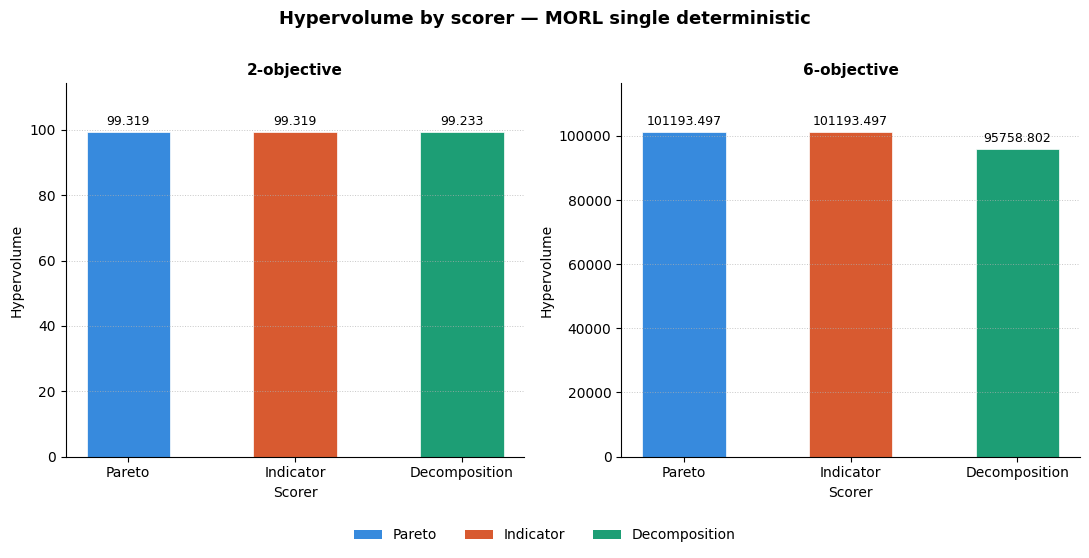

In [5]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from morl_baselines.common.performance_indicators import hypervolume

# ── Style config ──────────────────────────────────────────────────────────────
SCORING_LABELS = {
    "pareto":        "Pareto",
    "indicator":     "Indicator",
    "decomposition": "Decomposition",
}
SCORING_COLORS = {
    "pareto":        "#378ADD",
    "indicator":     "#D85A30",
    "decomposition": "#1D9E75",
}

SCORINGS = ["pareto", "indicator", "decomposition"]
OBJ_MAP  = {"multi_obj": 2, "many_obj": 6}


# ── Loader ────────────────────────────────────────────────────────────────────
def load_dataset(base):
    """
    Folder pattern: {scoring}_single_{multi|many}_obj
    Reads pcs_*.csv (positive values, maximisation convention).
    Returns DataFrame: scoring, n_obj, hv
    """
    folder_re = re.compile(
        r'^(pareto|indicator|decomposition)_single_(multi|many)_obj$'
    )
    records = []
    for d in os.listdir(base):
        m = folder_re.match(d)
        if not m:
            continue
        scoring  = m.group(1)
        n_obj    = OBJ_MAP[f"{m.group(2)}_obj"]
        folder_path = os.path.join(base, d)

        csvs = sorted([f for f in os.listdir(folder_path)
                       if f.startswith('pcs_') and f.endswith('.csv')])
        if not csvs:
            continue

        df = pd.read_csv(os.path.join(folder_path, csvs[0]))
        obj_cols = [c for c in df.columns if c.startswith('o')]
        if not obj_cols:
            continue

        vals = df[obj_cols].values
        ref  = np.full(len(obj_cols), -1.0)
        hv   = hypervolume(ref, [tuple(r) for r in vals]) if len(vals) > 0 else 0.0

        records.append({'scoring': scoring, 'n_obj': n_obj, 'hv': hv})

    return pd.DataFrame(records).sort_values(['n_obj', 'scoring'])


# ── Plotting helper ───────────────────────────────────────────────────────────
def plot_bars(ax, df, n_obj, title):
    """One bar per scorer with value label on top."""
    subset  = df[df['n_obj'] == n_obj]
    x       = np.arange(len(SCORINGS))
    hv_vals = [subset.loc[subset['scoring'] == s, 'hv'].values[0]
               if len(subset[subset['scoring'] == s]) > 0 else 0.0
               for s in SCORINGS]

    bars = ax.bar(x, hv_vals,
                  width=0.5,
                  color=[SCORING_COLORS[s] for s in SCORINGS],
                  edgecolor='white', linewidth=0.5)

    ax.bar_label(bars,
                 labels=[f'{v:.3f}' for v in hv_vals],
                 padding=3, fontsize=9)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Scorer', fontsize=10)
    ax.set_ylabel('Hypervolume', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([SCORING_LABELS[s] for s in SCORINGS])
    ax.set_ylim(0, max(hv_vals) * 1.15 if max(hv_vals) > 0 else 1)
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    BASE = './tree_data/morl_selector'
    OUT  = './tree_figures'
    os.makedirs(OUT, exist_ok=True)

    df = load_dataset(BASE)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharey=False)
    fig.suptitle('Hypervolume by scorer — MORL single deterministic',
                 fontsize=13, fontweight='bold', y=1.01)

    plot_bars(ax1, df, n_obj=2, title='2-objective')
    plot_bars(ax2, df, n_obj=6, title='6-objective')

    handles = [Patch(facecolor=SCORING_COLORS[s], label=SCORING_LABELS[s])
               for s in SCORINGS]
    fig.legend(handles=handles, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=10)

    fig.tight_layout()
    out_path = os.path.join(OUT, 'hv_morl_selector.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')